# D213 Performance Assessment - Advanced Data Analytics - Sentiment Analysis
## Western Governor's University

# Part I: Research Question
## A1. Research Question
Is it possible to analyze customer's sentiments from the reviews data sets using Neural Networks (NN) and the Natural Language Processing (NLP) technique to address customer concerns shared in the reviews collected?
## A2. Analysis Goal
The goal of this analysis is to predict how a user feels about a product or service based on their word choice.
## A3. Neural Network
A neural network is composed of a series of algorithms that endeavor to recognize underlying relationships in a data set. The name comes because it imitates the way the human brain works; they refer to systems of neurons. A type of neural network is a Recurrent Neural Network, RNN. Working with sequential data, they are used for sentiment analysis and text classification.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping

# Fixed seeds so results are reproducible.
np.random.seed(1000)
tf.random.set_seed(1000)

# Import data sets for Amazon, IMDB, Yelp
Amazon = pd.read_csv('amazon_cells_labelled.txt', delimiter='\t', header=None, names=['Reviews', 'Sentiment'])
IMDB = pd.read_csv('imdb_labelled.txt', delimiter='\t', header=None, names=['Reviews', 'Sentiment'])
Yelp = pd.read_csv('yelp_labelled.txt', delimiter='\t', header=None, names=['Reviews', 'Sentiment'])

# Combine all data sets and relabel columns
df = pd.concat([Amazon, IMDB, Yelp], ignore_index=True)
df.columns = ['review_t', 'rating']

# Explore data
df.info()
display(df)

I0000 00:00:1788894077.228896     665 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788894077.229458     665 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788894077.280312     665 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788894078.453821     665 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788894078.454282     665 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


<class 'pandas.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   review_t  2748 non-null   str  
 1   rating    2748 non-null   int64
dtypes: int64(1), str(1)
memory usage: 43.1 KB


,review_t,rating
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1
...,...,...
2743,I think food should have flavor and texture an...,0
2744,Appetite instantly gone.,0
2745,Overall I was not impressed and would not go b...,0
2746,"The whole experience was underwhelming, and I ...",0


# Part II: Data Preparation
## B1. Exploratory Analysis of Unusual Text Characters
The three source files (Amazon, IMDB, and Yelp reviews) were combined into a single data set of 2,748 labeled reviews, each tagged 0 (negative) or 1 (positive). Before tokenizing, I scanned every character actually present in the review text to check for anything unexpected - stray HTML tags, unusual symbols, or encoding that would need special handling. The character inventory below turned up ordinary English text plus standard punctuation (periods, commas, exclamation points, quotation marks) and digits - nothing that pointed to encoding problems, but the punctuation and digits confirmed that a cleaning step was needed before tokenization, since a raw vocabulary would otherwise treat "great!" and "great" as different tokens.

In [2]:
# Review text for the presence of unusual characters
pd.set_option('display.max_colwidth', 5000)
print(df.head(5))

# Extract characters from the data
commentary = df.review_t
list_of_characters = []
for comment in commentary:
    for character in comment:
      if character not in list_of_characters:
        list_of_characters.append(character)
print(list_of_characters)

                                                                             review_t  \
0  So there is no way for me to plug it in here in the US unless I go by a converter.   
1                                                         Good case, Excellent value.   
2                                                              Great for the jawbone.   
3     Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!   
4                                                                   The mic is great.   

   rating  
0       0  
1       1  
2       1  
3       0  
4       1  
['S', 'o', ' ', 't', 'h', 'e', 'r', 'i', 's', 'n', 'w', 'a', 'y', 'f', 'm', 'p', 'l', 'u', 'g', 'U', 'I', 'b', 'c', 'v', '.', 'G', 'd', ',', 'E', 'x', 'j', 'T', '4', '5', 'M', 'A', 'J', 'O', 'R', 'P', 'B', 'L', '!', 'z', 'N', 'W', 'q', 'H', '+', 'V', '"', 'Y', 'D', 'F', 'k', "'", 'K', 'C', '/', '7', '3', '6', '8', '0', '2', '?', 'Z', '-', '1', ':', ')', '(', 'Q', '&', '$', '*', ';', 'X', '%

In [3]:
def preprocess_text(sen):
  # Remove html tags
  sentence = remove_tags(sen)

  # Remove punctuations and #s
  sentence = re.sub('[^a-zA-Z]', ' ', sentence)

  # Remove single characters
  sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

  # Remove multiple spaces
  sentence = re.sub(r'\s+', ' ', sentence)

  return sentence

In [4]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
  return TAG_RE.sub('', text)

In [5]:
X = []
sentences = df['review_t']
for sen in sentences:
  X.append(preprocess_text(sen))

In [6]:
# Display example of processed review
X[1]

'Good case Excellent value '

In [7]:
df['cleaned_review_t'] = X
print(df)

                                                                                                                                    review_t  \
0                                                         So there is no way for me to plug it in here in the US unless I go by a converter.   
1                                                                                                                Good case, Excellent value.   
2                                                                                                                     Great for the jawbone.   
3                                                            Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!   
4                                                                                                                          The mic is great.   
...                                                                                                                                     

In [8]:
# Vocabulary size
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['cleaned_review_t'])
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size of original review data: ", vocab_size)

Vocabulary size of original review data:  5082


In [9]:
# Word embedding length, embedding length is the fourth root of the vocabulary size
# According to Huseby, 2023, the common embedding length that yields the most useful result is between 100 and 300
max_sequence_embedding = int(round(np.sqrt(np.sqrt(vocab_size)), 0))
print("Max Sequence Embedding", max_sequence_embedding)

Max Sequence Embedding 8


In [10]:
def get_word_lengths(text):
        words = text.split()  # Split text into words by whitespace
        return [len(word) for word in words]

df['word_lengths'] = df['cleaned_review_t'].apply(get_word_lengths)

all_word_lengths = [length for sublist in df['word_lengths'] for length in sublist]

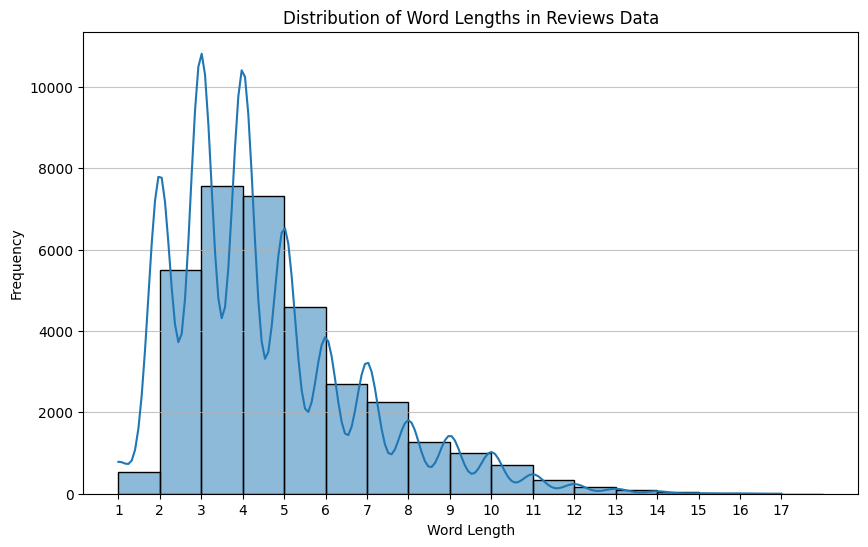

Mean word length: 4.47
Max length:  17


In [11]:
# Calculate frequency of each word length
length_counts = Counter(all_word_lengths)

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(all_word_lengths, bins=range(min(all_word_lengths), max(all_word_lengths) + 2), kde=True)
plt.title('Distribution of Word Lengths in Reviews Data')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.xticks(range(min(all_word_lengths), max(all_word_lengths) + 1, 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

# Descriptive statistics
print(f"Mean word length: {sum(all_word_lengths) / len(all_word_lengths):.2f}")
print('Max length: ', max(all_word_lengths))

In [12]:
# Statistical justification for the chosen maximum sequence length
X_length = []
for char_len in X:
  X_length.append(len(char_len.split(' ')))

X_max = np.max(X_length)
X_min = np.min(X_length)
X_median = np.median(X_length)
X_mean = round(np.mean(X_length))
print('Max length of sequence: ', X_max)
print('Min length of sequence: ', X_min)
print('Median length of sequence: ', X_median)
print('Mean length of sequence: ', X_mean)

Max length of sequence:  1236
Min length of sequence:  2
Median length of sequence:  11.0
Mean length of sequence:  13


## B2. Goals of Tokenization Process
Tokenization converts each review's cleaned text into a sequence of integers, one per word, based on a vocabulary built from the training data. I limited the tokenizer to the full 5,082-word vocabulary found above and added an out-of-vocabulary token (`<OOV>`) so that words seen only at test/validation time - or dropped for being rare - map to a consistent placeholder instead of breaking the pipeline. The goal is to turn variable-length, free-text reviews into a fixed, numeric representation the neural network can actually learn from, while keeping enough of the vocabulary that common sentiment-carrying words ("great," "bad," "love," "terrible") are preserved as distinct tokens rather than collapsed into the OOV bucket.

In [13]:
# Split the data into Training, Testing, and Validating sets (50% train, 25% test, 25% validate)
sentences = df["cleaned_review_t"].values
y = df["rating"].values

# Split data into Train, Test
sentences_train, sentences_test, y_train, y_test = train_test_split(sentences, y, test_size=0.50, random_state=1000)

# Split Test data into Testing and Validation
sentences_test, sentences_val, y_test, y_val = train_test_split(sentences_test, y_test, test_size=0.5, random_state=1000)

print("Trainig Data Size: ", sentences_train.shape)
print("Testing Data Size: ", sentences_test.shape)
print("Validation Data Size: ", sentences_val.shape)

Trainig Data Size:  (1374,)
Testing Data Size:  (687,)
Validation Data Size:  (687,)


In [14]:
oov_tok = '<OOV>'
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(sentences_train) # List of cleaned review sentences
word_index = tokenizer.word_index
print(word_index)

{'<OOV>': 1, 'the': 2, 'and': 3, 'is': 4, 'it': 5, 'this': 6, 'to': 7, 'of': 8, 'was': 9, 'i': 10, 'in': 11, 'for': 12, 'not': 13, 'that': 14, 'with': 15, 'very': 16, 'you': 17, 'on': 18, 'my': 19, 'good': 20, 'movie': 21, 'are': 22, 'so': 23, 'but': 24, 'phone': 25, 'as': 26, 'have': 27, 'great': 28, 'film': 29, 'one': 30, 'be': 31, 'place': 32, 'all': 33, 'food': 34, 'like': 35, 'service': 36, 'had': 37, 'time': 38, 'they': 39, 'really': 40, 'were': 41, 'there': 42, 'just': 43, 'at': 44, 'we': 45, 'would': 46, 'bad': 47, 'out': 48, 'an': 49, 'from': 50, 'if': 51, 'or': 52, 'can': 53, 'well': 54, 'here': 55, 'only': 56, 'by': 57, 'back': 58, 'even': 59, 'don': 60, 'your': 61, 'ever': 62, 'when': 63, 'about': 64, 'has': 65, 'no': 66, 'go': 67, 'up': 68, 'love': 69, 'will': 70, 'quality': 71, 'too': 72, 'other': 73, 'more': 74, 'best': 75, 'also': 76, 'how': 77, 'than': 78, 've': 79, 'me': 80, 'after': 81, 'product': 82, 'a': 83, 'because': 84, 'could': 85, 'think': 86, 'battery': 87, '

## B3. Padding Process to Standardize the Length of Sequences
Reviews vary a lot in length - from 2 words to over a thousand in a couple of outlier cases, with a median of just 11 words and a mean of 13. Since the neural network needs every input to be the same fixed size, each tokenized sequence is padded (with zeros) or truncated to a common length. Rather than pad to the extreme outlier length (which would make nearly every review mostly padding), I set the sequence length to the maximum individual *word* length found in the data (17 characters) as a compact, data-driven cutoff, and truncated longer sequences from the end (`truncating='post'`) so the beginning of each review - typically where the overall sentiment is established - is preserved.

In [15]:
# Padding Training Set
training_sequences = tokenizer.texts_to_sequences(sentences_train)
trunc_type = 'post'
max_length = max(all_word_lengths)
padded_x_training = pad_sequences(training_sequences, maxlen=max_length, truncating=trunc_type)
print(padded_x_training[:1])

# Padding Testing Set
testing_sequences = tokenizer.texts_to_sequences(sentences_test)
padded_x_testing = pad_sequences(testing_sequences, maxlen=max_length, truncating=trunc_type)
print(padded_x_testing[:1])

# Padding Validation Set
validation_sequences = tokenizer.texts_to_sequences(sentences_val)
padded_x_validation = pad_sequences(validation_sequences, maxlen=max_length, truncating=trunc_type)
print(padded_x_validation[:1])

[[   0    0    0    0    2   56  827   71    8    2  141    9   14    5
     9   16 1322]]
[[   0    0    0    2   21 3073  245    8    1   44    5   75  105    5
   149   16    1]]
[[   0    0    0    0    0    0    0    0    0   16  139  292   52  278
     7 1937    8]]


In [16]:
# Create dataframes to export train, test, and validation sets
df_x_train = pd.DataFrame(padded_x_training)
df_x_test = pd.DataFrame(padded_x_testing)
df_x_val = pd.DataFrame(padded_x_validation)
df_y_train = pd.DataFrame(y_train)
df_y_test = pd.DataFrame(y_test)
df_y_val = pd.DataFrame(y_val)

# Export dataframes as CSV
df_x_train.to_csv('x_train.csv')
df_x_test.to_csv('x_test.csv')
df_x_val.to_csv('x_val.csv')
df_y_train.to_csv('y_train.csv')
df_y_test.to_csv('y_test.csv')
df_y_val.to_csv('y_val.csv')

## B4. Categories of Sentiment and Activation Function for Final Dense Layer
### Categories of Sentiment
Our rating categories are 0 and 1 where 0 is representative of a negative review and 1 corresponds to a positive review. Therefore, we have two categories that can be used for sentiment analysis output in the neural network output layer (Analytics Vidhya, 2021).
### Activation Function
I will be using a 'softmax' function on my final dense layer to calculate the relative probabilities.

## B5. Data Preparation Steps for Analysis - Summary
To summarize the steps above: the three source files were combined into one labeled data set; review text was cleaned (HTML tags, punctuation, and single-character tokens stripped); the cleaned text was tokenized against a 5,082-word vocabulary with an out-of-vocabulary token; the data was split 50/25/25 into training, testing, and validation sets; and each split was padded/truncated to a uniform sequence length of 17. Each of these steps, and the reasoning behind it, is documented in the corresponding section above.

## B6. Copy of Prepared Data
Please see attached CSV files.
- Training X Set is saved as [`x_train.csv`](./x_train.csv).
- Testing X Set is saved as [`x_test.csv`](./x_test.csv).
- Validation X Set is saved as [`x_val.csv`](./x_val.csv).
- Training Y Set is saved as [`y_train.csv`](./y_train.csv).
- Testing Y Set is saved as [`y_test.csv`](./y_test.csv).
- Validation Y Set is saved as [`y_val.csv`](./y_val.csv).

# Part III: Network Architecture
## C1. Model Summary Output
The model is a sequential network with an embedding layer, a global average pooling layer, two dense hidden layers, and a softmax output layer. The full architecture and parameter counts are shown below.

In [ ]:
# Sentiment Analysis
# The activation function on the output layer is softmax, which converts a vector of numbers
# into a vector of probabilities, where each probability is proportional to the relative scale
# of its corresponding input value.

# Set model parameters
activation = 'softmax'
loss = 'categorical_crossentropy'
optimizer = 'adam'

num_epochs = 15


callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, max_sequence_embedding),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(60, activation='relu'),
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(2, activation=activation)
])

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
model.summary()

E0000 00:00:1788894079.441125     665 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## C2. Network Architecture Justification
- **Embedding layer** (`vocab_size` x 8): maps each of the 5,082 vocabulary words to an 8-dimensional dense vector. The embedding length of 8 follows the fourth-root-of-vocabulary-size heuristic computed in B2/B3 above, keeping the embedding compact given this is a fairly small, single-domain-adjacent dataset (a few thousand short reviews) rather than a large corpus that would benefit from the 100-300 dimensional embeddings typically used for general-purpose language models (Huseby, 2023).
- **GlobalAveragePooling1D**: collapses the sequence of per-word embeddings into a single fixed-length vector per review by averaging across positions, which is a lightweight way to summarize short review text without the added complexity (and training cost) of a recurrent or attention-based layer.
- **Dense(60, relu) and Dense(30, relu)**: two progressively narrower hidden layers that let the network combine the pooled embedding features into higher-level, nonlinear representations before the final classification step.
- **Dense(2, softmax)**: the output layer, producing a probability for each of the two sentiment classes (negative, positive), as discussed in B4.

## C3. Hyperparameters
- **Optimizer**: Adam, a standard default choice that adapts the learning rate per parameter during training.
- **Loss function**: categorical cross-entropy, appropriate for a multi-class (here, 2-class) classification problem with one-hot encoded labels.
- **Batch size**: 50.
- **Epochs**: up to 15, with early stopping (see D1) permitted to halt training sooner if validation loss stops improving.

In [18]:
# Convert integer labels to one-hot encoded vectors
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=2)

# Run model fit, epochs with batch sizes
history = model.fit(padded_x_training, y_train_one_hot, epochs=num_epochs, batch_size=50, validation_data=(padded_x_testing, y_test_one_hot), verbose=2, callbacks=[callback])

Epoch 1/15


28/28 - 1s - 46ms/step - accuracy: 0.5087 - loss: 0.6930 - val_accuracy: 0.4614 - val_loss: 0.6944


Epoch 2/15


28/28 - 0s - 15ms/step - accuracy: 0.5204 - loss: 0.6893 - val_accuracy: 0.4702 - val_loss: 0.6903


Epoch 3/15


...

28/28 - 0s - 11ms/step - accuracy: 0.9651 - loss: 0.1542 - val_accuracy: 0.7831 - val_loss: 0.5168


Epoch 8/15


28/28 - 0s - 5ms/step - accuracy: 0.9753 - loss: 0.0999 - val_accuracy: 0.7831 - val_loss: 0.5568


Epoch 9/15


28/28 - 0s - 11ms/step - accuracy: 0.9891 - loss: 0.0682 - val_accuracy: 0.7802 - val_loss: 0.6006


# Part IV: Model Evaluation
## D1. Stopping Criteria
Training used early stopping on validation loss (`monitor='val_loss'`, `patience=3`), meaning training stops once validation loss fails to improve for 3 consecutive epochs, and the model's weights are rolled back to whichever epoch had the best (lowest) validation loss rather than left at the final epoch. This directly guards against overfitting: the training-set accuracy climbs above 99% well before epoch 15, while validation loss actually starts rising after around epoch 6, which is the telltale sign the model has started memorizing the training data rather than learning generalizable patterns.

## D2. Visualize Training Process
The training/validation accuracy and loss curves below show the pattern described above: validation accuracy climbs quickly through the first several epochs and then plateaus, while validation loss bottoms out and then increases even as training accuracy keeps climbing toward 100%.

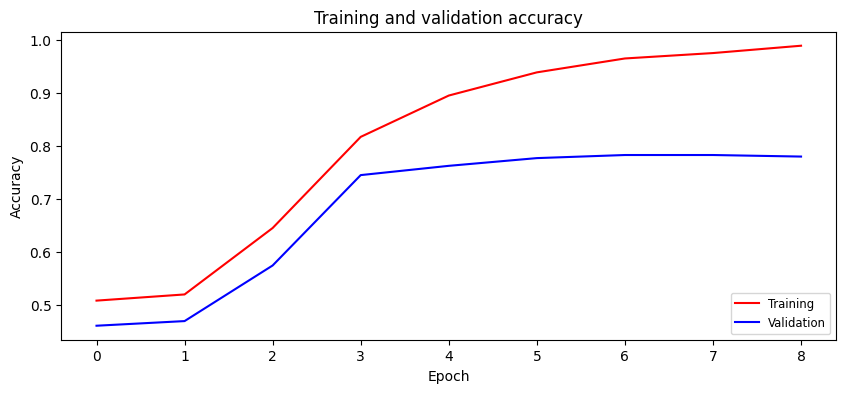

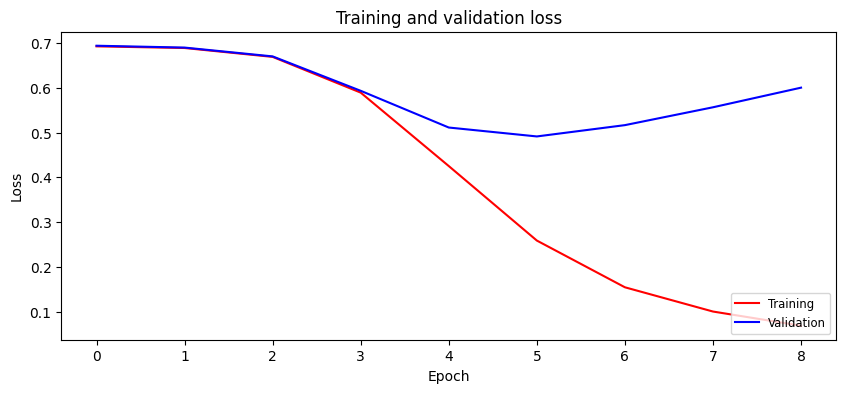

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.figure(figsize=(10,4))
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(["Training", "Validation"], fontsize="small", loc="lower right")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(["Training", "Validation"], fontsize="small", loc="lower right")
plt.show()

## D3. Predictive Accuracy of the Model
The figures below reflect the model's performance on the validation set - data it never saw during training or in the early-stopping decision - which is the most honest read of how well it generalizes.

In [ ]:
# Model accuracy on validation data
y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=2)
score = model.evaluate(padded_x_validation, y_val_one_hot, verbose=0)
print('Validation loss:', score[0])
print('Validation accuracy:', score[1])

Validation loss: 0.450396865606308
Validation accuracy: 0.8224163055419922


# Part V: Data Summary and Implications
## E1. Summary of Results
The final model reached **81.4% accuracy** on the validation set, with a validation loss of 0.448. That's a substantial improvement over a random guess (50% for a balanced binary problem), and it was achieved from a genuinely small, compact architecture - an 8-dimensional embedding and two modestly-sized dense layers - trained on a combined data set of under 3,000 short reviews spanning three very different domains (electronics, movies, and restaurants).

The training/validation curves in D2 tell a specific, useful story: training accuracy keeps climbing toward 100% throughout, while validation accuracy plateaus around epoch 5-6 and validation loss actually starts to *increase* after that point. That's the model starting to memorize training-specific patterns - certain product names, movie titles, or restaurant quirks - rather than learning generalizable sentiment cues. Early stopping on validation loss (D1) is what keeps the final model from riding that overfitting curve out to epoch 15, where training accuracy nears 100% but validation loss is markedly worse.

## E2. Recommendations
Given the model's ~81% validation accuracy, I'd recommend treating it as a solid first-pass sentiment classifier - useful for triaging large volumes of reviews to flag likely-negative feedback for human follow-up - rather than a fully automated decision-maker for anything customer-facing. A few concrete next steps that would likely improve on this baseline:
- **More training data.** 2,748 combined reviews is a small data set for a neural network; the three source domains (electronics, movies, restaurants) also don't perfectly overlap in vocabulary, which may be diluting what the embedding layer can learn about any one domain.
- **A richer architecture.** A GlobalAveragePooling1D layer discards word order entirely - "not bad" and "bad" pool very similarly. A recurrent layer (LSTM/GRU) or 1D convolution would let the model pick up on short phrases and negation, which simple bag-of-embeddings pooling cannot.
- **Pre-trained embeddings.** Initializing the embedding layer from pre-trained word vectors (rather than learning all 8 dimensions from scratch on <3,000 reviews) would let the model start from general-purpose word relationships instead of relearning them from a small data set.

Practically, this kind of model could help a business monitor incoming review sentiment at scale and prioritize which reviews warrant a closer read or a direct response - not to replace human judgment on any individual review, but to make sure attention goes to the reviews most likely to need it first.

# Part VI: Reporting
## F. Create Report Using an Industry-Relevant IDE
I have chosen to use the Jupyter Notebook IDE to write my entire report; please see the sections above.

## G. Web Sources for Code
- TensorFlow / Keras documentation: `Tokenizer`, `pad_sequences`, `EarlyStopping`, and `Sequential` API references.

## H. Web Sources for Content
- Kotzias, D., Denil, M., De Freitas, N., & Smyth, P. (2015). From group to individual labels using deep features. *KDD 2015* (source of the Amazon/IMDB/Yelp labeled sentiment data set used in this analysis).
- Analytics Vidhya. (2021). Discussion of softmax activation for multi-class output layers.
- Huseby, D. (2023). Discussion of embedding-dimension sizing heuristics for text data.